In [3]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.7 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.7 MB 1.7 MB/s eta 0:00:01
   ------------------ --------------------- 0.8/1.7 MB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.5 MB/s  0:00:01

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -------- ------------------------------- 1/5 [multitasking]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [webso

# Choose Stock & Load Data

In [4]:
import yfinance as yf
import pandas as pd

# Load data
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Reset index (important for handling date)
df.reset_index(inplace=True)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
3,2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
4,2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


#### The stock data was successfully fetched using the yfinance library. The dataset contains historical records including Open, 

#### High, Low, Close and Volume.

# Understand the Data

In [5]:
print(df.shape)

(1006, 6)


In [6]:
print(df.columns)

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1006 non-null   datetime64[ns]
 1   (Close, AAPL)   1006 non-null   float64       
 2   (High, AAPL)    1006 non-null   float64       
 3   (Low, AAPL)     1006 non-null   float64       
 4   (Open, AAPL)    1006 non-null   float64       
 5   (Volume, AAPL)  1006 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.3 KB
None


#### The dataset is time-series in nature, ordered by date. No major missing values were observed so it was ready for modeling.

# Create Target Variable

In [8]:
df['Next_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)

#### A new column (Next_Close) was created by shifting the closing price to represent the next day’s value. This allows the model

#### to learn and predict future prices.

# Features & Target

In [9]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

#### Open, High, Low, and Volume were used as input features as they directly influence stock price movements.

# Train-Test Split (Time Series way)

In [10]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#### The dataset was split chronologically into training and testing sets to maintain the time dependency and avoid data leakage.

# Train RandomForest Model

In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### A Random Forest Regressor was trained on the dataset. It was chosen because it can capture non-linear patterns in stock 

#### price movements.

# Predictions

In [17]:
y_pred = model.predict(X_test)
y_pred

array([151.31650879, 151.11267197, 152.50565063, 157.30067917,
       154.72899399, 158.90785019, 154.64738724, 156.14877701,
       156.95089371, 156.88669174, 157.08910828, 160.86277161,
       158.87846939, 163.00078125, 163.34701126, 163.05148788,
       163.00547928, 162.81949768, 159.15219269, 159.27658081,
       159.10458542, 161.19782654, 163.4500824 , 163.48483414,
       164.7391655 , 165.06003143, 164.89860855, 163.154478  ,
       163.24739685, 162.76204361, 164.35612442, 163.45325165,
       164.83750122, 164.82057297, 164.53257843, 165.89995148,
       163.55870407, 170.2864151 , 170.52438553, 170.14649506,
       170.33299683, 169.72737488, 169.97276993, 169.77698029,
       170.7434697 , 169.19501587, 170.14043228, 175.18681961,
       170.15274673, 169.9428157 , 167.36760742, 170.58527344,
       170.18771988, 174.24074478, 173.7481897 , 174.90156143,
       173.05380386, 172.46123276, 173.48289505, 174.10118576,
       173.92356964, 172.94828033, 172.94828033, 172.94

#### The model generated predictions for the test data estimating the next day’s closing prices.

# Plotting

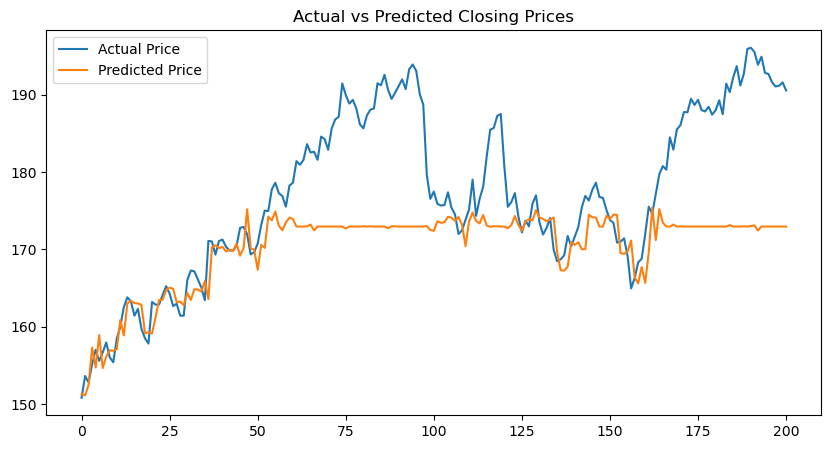

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

#### The plotted graph of actual vs predicted prices shows that the model follows the overall trend although slight differences exist.

# MAE (Mean Absolute Error)

In [14]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 7.4465440566029715


# MSE (Mean Squared Error)

In [15]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 105.13959011424515


# R² Score

In [16]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.1050772934515769


#### MAE and MSE indicate the prediction error while the R² score shows how well the model explains the variance in stock prices.

# Overall Insight

#### The model performs reasonably well in capturing trends but perfect accuracy is not possible due to the inherent volatility

#### of stock market data.